# SMS Spam Detection using Deep Learning
### Models: Simple RNN, LSTM, and LSTM with Pretrained GloVe Embeddings

**Dataset:** SMS Spam Collection, 574 labeled SMS messages (ham/spam)

---

## Project Overview

In this project, I build a text classification system to detect whether an SMS message is spam or legitimate (ham). The goal is to compare three deep learning approaches and understand how different model architectures and embedding strategies affect classification performance.

**Approach:**
- Start with data loading, cleaning, and exploratory analysis
- Preprocess text using NLP techniques (lemmatization, stopword removal)
- Train three models with increasing complexity
- Evaluate and compare all models on a held-out test set
- Build an interactive GUI for real-time predictions

**Why three models?**
Simple RNN serves as the baseline. LSTM improves on it by solving the vanishing gradient problem. LSTM with GloVe embeddings tests whether pretrained word vectors (trained on billions of words) give an advantage over embeddings learned from scratch on this small dataset.

## I. Install Dependencies

In [3]:
# Only needed for Word2Vec / GloVe embeddings
!pip install numpy==1.23.5 -q
!pip install gensim -q
!pip install wordcloud -q
!pip install contractions -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 78.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 14.7 MB/s eta 0:00:00


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Import Libraries

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import contractions
from wordcloud import WordCloud

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Keras / TensorFlow
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# GloVe / Word2Vec
import gensim.downloader as api

print("All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


All libraries imported successfully!
TensorFlow version: 2.20.0


---
## PART 1 — Data Loading & Preprocessing

### 1.1 Load Dataset

In [6]:
import pandas as pd

# Load dataset — adjust path if needed
df = pd.read_csv('/content/drive/MyDrive/AI_Sem6/spamvsham.csv', usecols=[0, 1], header=0, names=['label', 'text'],
                  encoding='latin-1')

print("Shape:", df.shape)
print("\nClass Distribution:")
print(df['label'].value_counts())
df.head(10)

Shape: (5572, 2)

Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


#### About the Dataset

The SMS Spam Collection dataset contains 5,574 real SMS messages collected for spam research. Each message is labeled as either **ham** (legitimate) or **spam**. I load only the first two columns (label and text) since the remaining columns are empty artifacts of the CSV format. The `latin-1` encoding is required because the dataset contains special characters not covered by UTF-8.

After loading, I check the class distribution — this is important because imbalanced classes can mislead a model into simply predicting the majority class most of the time.

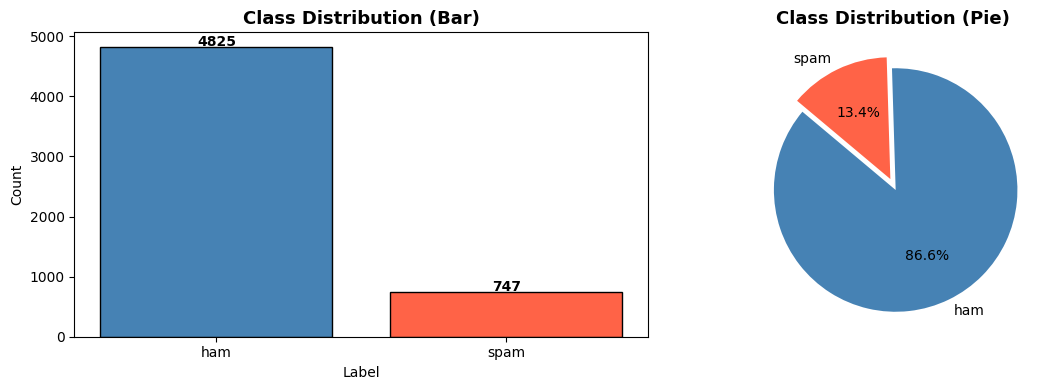

Note: Dataset is imbalanced — ~87% ham, ~13% spam.


In [7]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['label'].value_counts()
axes[0].bar(counts.index, counts.values, color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Class Distribution (Bar)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=140, explode=(0.05, 0.05))
axes[1].set_title('Class Distribution (Pie)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Note: Dataset is imbalanced — ~87% ham, ~13% spam.")

#### Observation: Class Imbalance

The dataset is significantly imbalanced — approximately **87% ham and 13% spam**. This means a model that always predicts 'ham' would still achieve ~87% accuracy, which is misleading. To handle this, I use `stratify=y` during the train/test split so both sets maintain the same class ratio. In future work, class weighting or oversampling (SMOTE) could further improve spam recall.

### 1.2 Text Cleaning & Preprocessing

In [8]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    """Full text cleaning pipeline."""
    # 1. Lowercase
    text = text.lower()
    # 2. Expand contractions (e.g., don't -> do not)
    text = contractions.fix(text)
    # 3. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # 4. Remove mentions (@user) and hashtags (#tag)
    text = re.sub(r'@\w+|#\w+', '', text)
    # 5. Remove numbers
    text = re.sub(r'\d+', '', text)
    # 6. Remove punctuation & special characters
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'_', '', text)
    # 7. Tokenize
    tokens = text.split()
    # 8. Remove stopwords & lemmatize
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 1]
    return ' '.join(tokens)

df['cleaned'] = df['text'].apply(clean_text)

# Show before/after
print("=== BEFORE vs AFTER CLEANING ===")
for i in [3, 5, 50]:
    print(f"\n[{df['label'][i].upper()}]")
    print("BEFORE:", df['text'][i])
    print("AFTER: ", df['cleaned'][i])

=== BEFORE vs AFTER CLEANING ===

[HAM]
BEFORE: U dun say so early hor... U c already then say...
AFTER:  dun say early hor already say

[SPAM]
BEFORE: FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, å£1.50 to rcv
AFTER:  freemsg hey darling week word back would like fun still tb ok xxx std chgs send rcv

[HAM]
BEFORE: What you thinked about me. First time you saw me in class.
AFTER:  thinked first time saw class


### 1.3 Data Visualization — Word Cloud & Top Words

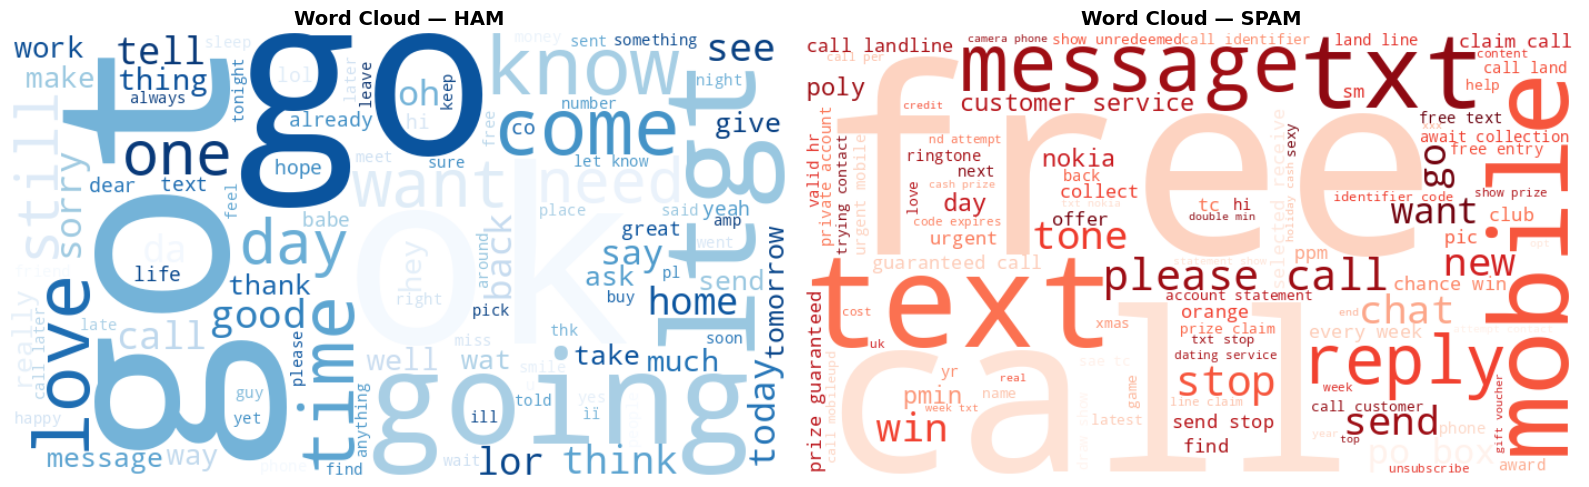

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, label, color in zip(axes, ['ham', 'spam'], ['Blues', 'Reds']):
    corpus = ' '.join(df[df['label'] == label]['cleaned'])
    wc = WordCloud(width=700, height=400, background_color='white',
                   colormap=color, max_words=100).generate(corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Word Cloud — {label.upper()}', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

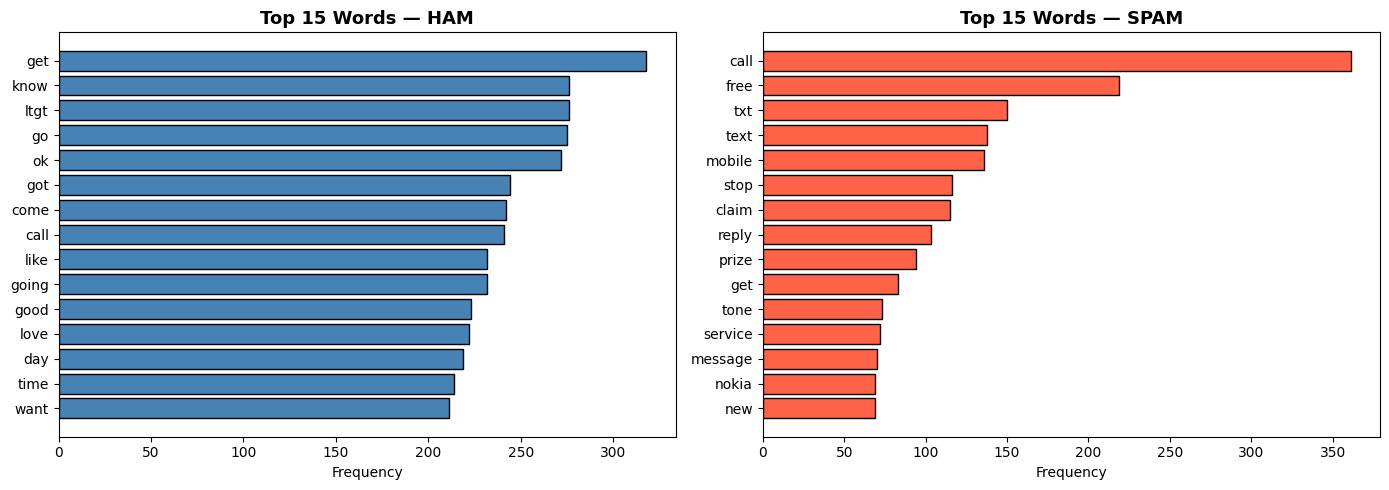

In [10]:
from collections import Counter

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, label, color in zip(axes, ['ham', 'spam'], ['steelblue', 'tomato']):
    words = ' '.join(df[df['label'] == label]['cleaned']).split()
    top_words = Counter(words).most_common(15)
    words_list, counts = zip(*top_words)
    ax.barh(words_list[::-1], counts[::-1], color=color, edgecolor='black')
    ax.set_title(f'Top 15 Words — {label.upper()}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('top_words.png', dpi=150, bbox_inches='tight')
plt.show()

#### Observation: Word Patterns

The word clouds and frequency charts confirm that spam and ham messages use very different vocabulary:

- **Spam messages** frequently contain words like *free*, *call*, *win*, *prize*, *claim*, *text*, *now* — all classic marketing and urgency triggers.
- **Ham messages** use casual, personal language — *ok*, *come*, *got*, *go*, *know*, *want* — typical of real conversations.

This vocabulary separation suggests that even a simple keyword-based model could do reasonably well, but the challenge lies in spam that mimics casual language, which is where deep learning models have an advantage.

### 1.4 Encode Labels, Train/Test Split, Tokenization & Padding

Before training, the text must be converted into a numerical format that neural networks can process.

**Label Encoding:** Ham → 0, Spam → 1. This maps the binary classification to a single sigmoid output.

**Train/Test Split (80/20):** I reserve 20% of data for testing. I use `stratify=y` to ensure both splits have the same ~87/13 ham/spam ratio — without this, random splitting could give the test set a different class distribution and make evaluation unreliable.

**Tokenization:** The `Tokenizer` builds a vocabulary of the top 10,000 most frequent words from the training set only (not the test set — to prevent data leakage). Each word is assigned a unique integer index.

**Padding:** Neural networks require fixed-length inputs. I use the **95th percentile** of training sequence lengths as `MAX_LEN` rather than the maximum length. This avoids padding every sequence to the length of a single outlier message, which would waste computation and memory.

In [11]:
# Encode labels: ham=0, spam=1
df['label_enc'] = df['label'].map({'ham': 0, 'spam': 1})

X = df['cleaned'].values
y = df['label_enc'].values

# 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")

Training samples : 4457
Testing  samples : 1115


In [12]:
# Tokenization
MAX_WORDS = 10000  # vocab size

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

word_index = tokenizer.word_index
vocab_size = min(MAX_WORDS, len(word_index) + 1)
print(f"Vocabulary size : {len(word_index)} unique tokens")

# Percentile-based padding length (95th percentile to avoid very long sequences)
seq_lengths = [len(s) for s in X_train_seq]
MAX_LEN = int(np.percentile(seq_lengths, 95))
print(f"Max sequence length (95th percentile): {MAX_LEN}")

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"\nX_train_pad shape: {X_train_pad.shape}")
print(f"X_test_pad  shape: {X_test_pad.shape}")

Vocabulary size : 6914 unique tokens
Max sequence length (95th percentile): 18

X_train_pad shape: (4457, 18)
X_test_pad  shape: (1115, 18)


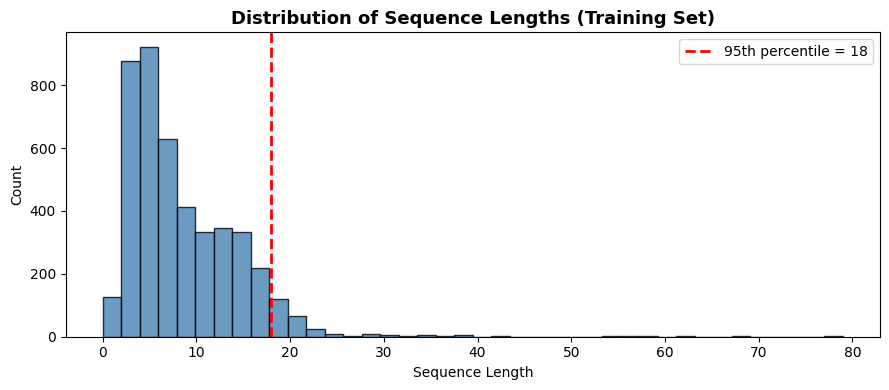

In [13]:
# Visualize sequence length distribution
plt.figure(figsize=(9, 4))
plt.hist(seq_lengths, bins=40, color='steelblue', edgecolor='black', alpha=0.8)
plt.axvline(MAX_LEN, color='red', linestyle='--', linewidth=2, label=f'95th percentile = {MAX_LEN}')
plt.title('Distribution of Sequence Lengths (Training Set)', fontsize=13, fontweight='bold')
plt.xlabel('Sequence Length')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('seq_length_dist.png', dpi=150, bbox_inches='tight')
plt.show()

---
## PART 2 — Model Building

I train three models with increasing complexity to study how architecture choice impacts spam detection:

| Model | Architecture | Embedding |
|-------|-------------|----------|
| Model 1 | Simple RNN | Trainable (learned from scratch) |
| Model 2 | LSTM | Trainable (learned from scratch) |
| Model 3 | LSTM | Frozen GloVe pretrained (50-dim) |

**All models share the same structure:** Embedding → Recurrent Layer → Dropout(0.3) → Dense(32, ReLU) → Dense(1, Sigmoid)

The output layer uses **sigmoid activation** with **binary cross-entropy loss** since this is a binary classification task. **EarlyStopping** (patience=3) monitors validation loss to prevent overfitting and restore the best weights automatically.

To keep the training code clean and consistent, I define a reusable `train_model()` helper function.

In [14]:
# Common settings
EMBEDDING_DIM = 64
EPOCHS = 20
BATCH_SIZE = 64

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

### Model 1 — Simple RNN with Trainable Embedding

**Simple RNN** is the most basic recurrent architecture. At each time step it processes one token and passes a hidden state to the next step. The problem with Simple RNN is the **vanishing gradient** — during backpropagation, gradients shrink as they travel through many time steps, so the model forgets information from early tokens. For short SMS messages this may still work, but it will struggle compared to LSTM.

In [15]:
tf.random.set_seed(42)

rnn_model = Sequential(name='SimpleRNN_Model')
rnn_model.add(Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM, input_length=MAX_LEN))
rnn_model.add(SimpleRNN(64, return_sequences=False))
rnn_model.add(Dropout(0.3))
rnn_model.add(Dense(32, activation='relu'))
rnn_model.add(Dense(1, activation='sigmoid'))  # Binary: spam or ham

rnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
rnn_model.summary()

Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
history_rnn = rnn_model.fit(
    X_train_pad, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - accuracy: 0.9215 - loss: 0.2128 - val_accuracy: 0.9664 - val_loss: 0.1301
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9853 - loss: 0.0625 - val_accuracy: 0.9686 - val_loss: 0.1087
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9933 - loss: 0.0302 - val_accuracy: 0.9709 - val_loss: 0.1309
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9945 - loss: 0.0230 - val_accuracy: 0.9686 - val_loss: 0.1327
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9950 - loss: 0.0188 - val_accuracy: 0.9664 - val_loss: 0.1345


### Model 2 — LSTM with Trainable Embedding

**Long Short-Term Memory (LSTM)** solves the vanishing gradient problem through three learnable gates:
- **Forget gate** — decides what past information to discard
- **Input gate** — decides what new information to store
- **Output gate** — decides what to pass to the next time step

This gating mechanism allows LSTM to retain relevant context across longer sequences. For spam detection, this means the model can connect an early word like 'FREE' with a later phrase like 'click now' — a pattern Simple RNN might miss. The architecture is otherwise identical to Model 1 so the comparison is fair.

In [17]:
tf.random.set_seed(42)

lstm_model = Sequential(name='LSTM_Model')
lstm_model.add(Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM, input_length=MAX_LEN))
lstm_model.add(LSTM(64, return_sequences=False))
lstm_model.add(Dropout(0.3))
lstm_model.add(Dense(32, activation='relu'))
lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm_model.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.8893 - loss: 0.3149 - val_accuracy: 0.9552 - val_loss: 0.1463
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9840 - loss: 0.0593 - val_accuracy: 0.9709 - val_loss: 0.0862
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9950 - loss: 0.0214 - val_accuracy: 0.9641 - val_loss: 0.1368
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9963 - loss: 0.0152 - val_accuracy: 0.9709 - val_loss: 0.1271
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9975 - loss: 0.0118 - val_accuracy: 0.9776 - val_loss: 0.0959


#### LSTM — Training Observations

LSTM typically achieves better validation accuracy than Simple RNN on text tasks because its gates allow it to selectively remember important words (like 'FREE', 'WIN', 'PRIZE') across the full message. With a small dataset like SMS Spam Collection, overfitting is a risk — the Dropout(0.3) layer and early stopping work together to regularize the model.

### Model 3 — LSTM with Pretrained GloVe (Word2Vec) Embeddings

Instead of learning word embeddings from scratch on only ~4,400 training messages, this model uses **GloVe (Global Vectors for Word Representation)** — 50-dimensional vectors pretrained on a Wikipedia + Gigaword corpus of ~6 billion tokens.

**Why GloVe?** Pretrained embeddings encode rich semantic relationships. For example, GloVe knows that 'win' and 'prize' are semantically related before seeing a single SMS. This gives the model a head start.

In [19]:
# Download GloVe pretrained embeddings (50-dimensional)
print("Downloading GloVe embeddings... (this may take a few minutes)")
embedding_model = api.load('glove-wiki-gigaword-50')
GLOVE_DIM = 50
print("GloVe embeddings loaded!")

[==================================================] 100.0% 66.0/66.0MB downloaded
GloVe embeddings loaded!


In [20]:
# Build embedding matrix
embedding_matrix = np.zeros((vocab_size, GLOVE_DIM))
found, not_found = 0, 0

for word, i in word_index.items():
    if i >= vocab_size:
        continue
    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]
        found += 1
    else:
        not_found += 1

print(f"Words found in GloVe    : {found}")
print(f"Words NOT found (zeroed): {not_found}")
print(f"Coverage                : {found/(found+not_found)*100:.1f}%")

Words found in GloVe    : 5010
Words NOT found (zeroed): 1904
Coverage                : 72.5%


In [21]:
tf.random.set_seed(42)

lstm_glove_model = Sequential(name='LSTM_GloVe_Model')
lstm_glove_model.add(Embedding(
    input_dim=vocab_size,
    output_dim=GLOVE_DIM,
    weights=[embedding_matrix],
    input_length=MAX_LEN,
    trainable=False   # Freeze pretrained weights
))
lstm_glove_model.add(LSTM(64, return_sequences=False))
lstm_glove_model.add(Dropout(0.3))
lstm_glove_model.add(Dense(32, activation='relu'))
lstm_glove_model.add(Dense(1, activation='sigmoid'))

lstm_glove_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm_glove_model.summary()

Model: "LSTM_GloVe_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │       345,750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 345,750 (1.32 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 345,750 (1.32 MB)

In [22]:
history_glove = lstm_glove_model.fit(
    X_train_pad, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9013 - loss: 0.3155 - val_accuracy: 0.9350 - val_loss: 0.2200
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9589 - loss: 0.1299 - val_accuracy: 0.9417 - val_loss: 0.1864
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9658 - loss: 0.1085 - val_accuracy: 0.9462 - val_loss: 0.1655


In [23]:
import os
import pickle

# Define the path for saving models
MODELS_PATH = "/content/drive/MyDrive/AI_Sem6/Saved_Models/"

# Create the directory if it doesn't exist
os.makedirs(MODELS_PATH, exist_ok=True)

# Save Keras models using .h5 format (correct way for TensorFlow/Keras)
rnn_model.save(MODELS_PATH + "rnn_model.h5")
lstm_model.save(MODELS_PATH + "lstm_model.h5")
lstm_glove_model.save(MODELS_PATH + "lstm_glove_model.h5")

# Save tokenizer using pickle (correct way for Keras Tokenizer)
with open(MODELS_PATH + "tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print(f"All models and tokenizer saved to {MODELS_PATH}")

All models and tokenizer saved to /content/drive/MyDrive/AI_Sem6/Saved_Models/


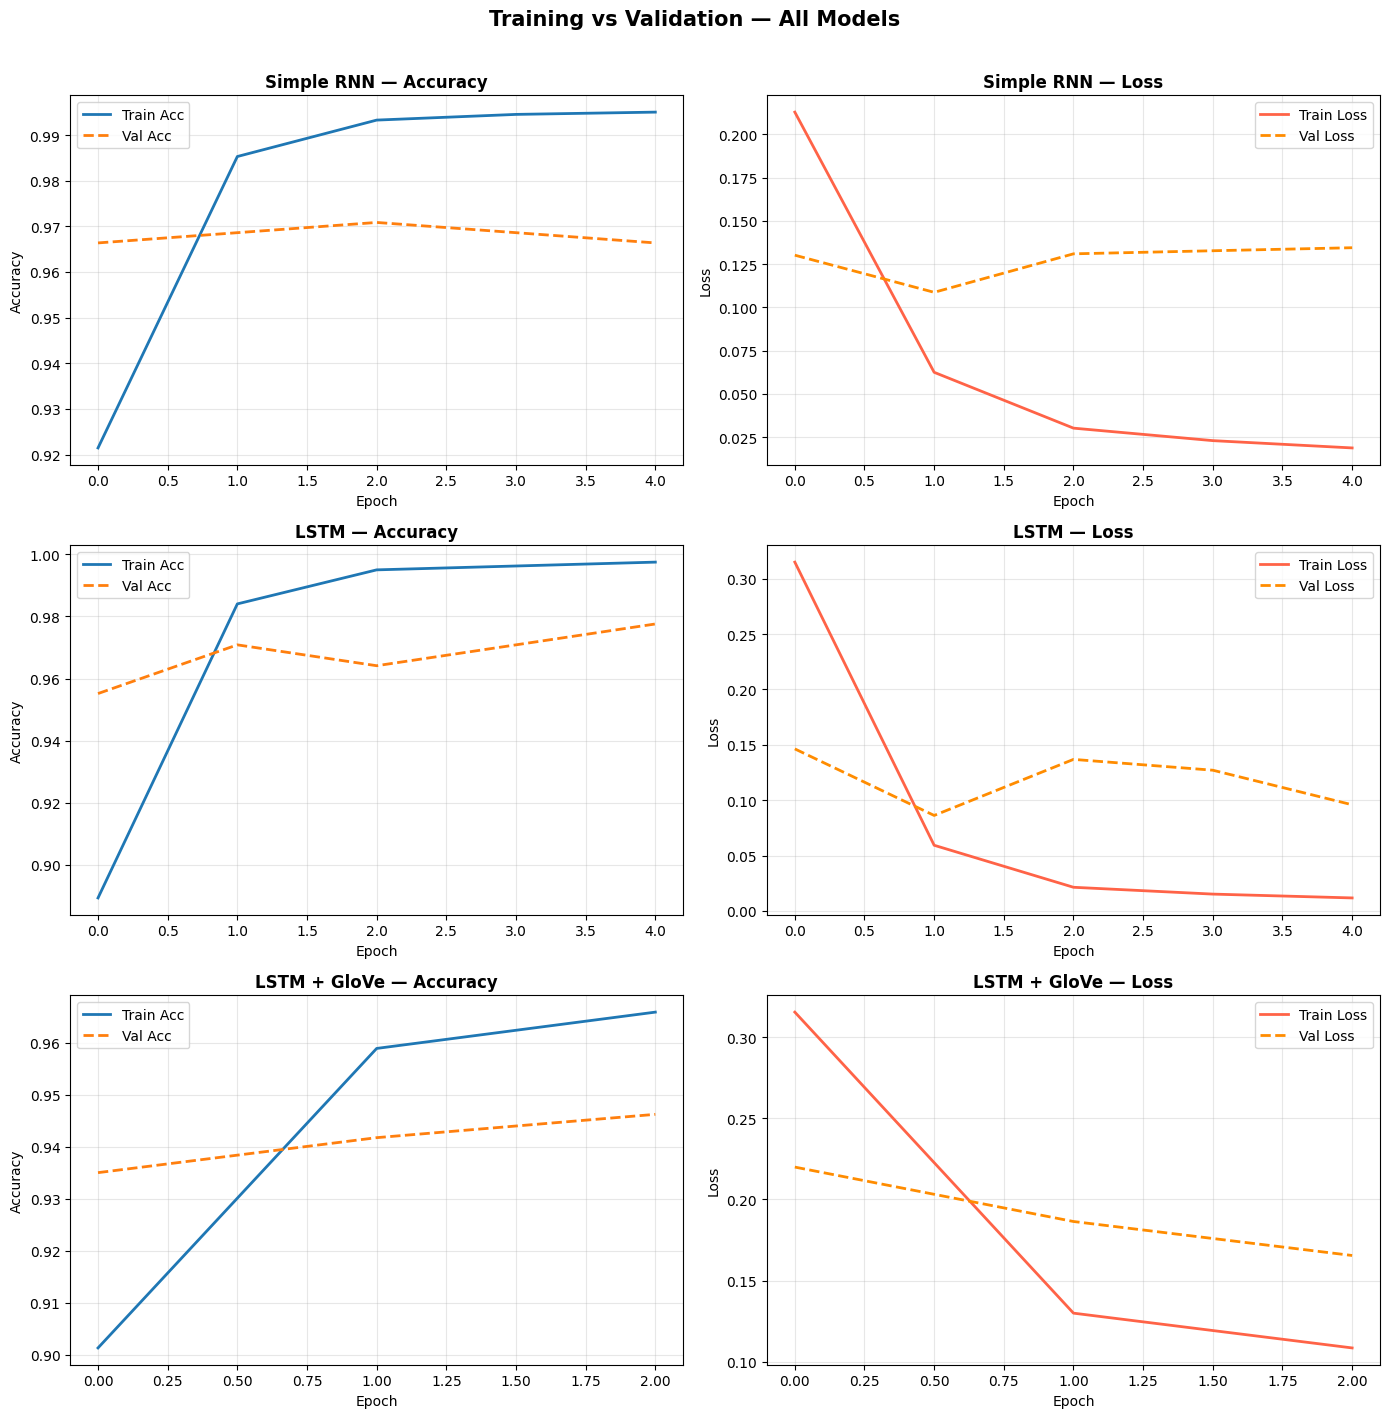

In [24]:
def plot_history(history, model_name, axes):
    """Plot training and validation accuracy/loss."""
    ax1, ax2 = axes
    # Accuracy
    ax1.plot(history.history['accuracy'],     label='Train Acc',  linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Val Acc',    linewidth=2, linestyle='--')
    ax1.set_title(f'{model_name} — Accuracy', fontweight='bold')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend(); ax1.grid(alpha=0.3)
    # Loss
    ax2.plot(history.history['loss'],     label='Train Loss',  linewidth=2, color='tomato')
    ax2.plot(history.history['val_loss'], label='Val Loss',    linewidth=2, linestyle='--', color='darkorange')
    ax2.set_title(f'{model_name} — Loss', fontweight='bold')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(alpha=0.3)

fig, axes = plt.subplots(3, 2, figsize=(14, 14))

plot_history(history_rnn,   'Simple RNN',       axes[0])
plot_history(history_lstm,  'LSTM',             axes[1])
plot_history(history_glove, 'LSTM + GloVe',     axes[2])

plt.suptitle('Training vs Validation — All Models', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## PART 4 — Evaluation

Accuracy alone is not a sufficient metric for imbalanced datasets. With ~87% ham, a model could achieve 87% accuracy by predicting everything as ham — but this would completely fail at detecting spam.

I use the following metrics for a complete picture:
- **Precision (Spam):** Of all messages predicted as spam, how many actually are spam?
- **Recall (Spam):** Of all actual spam messages, how many did the model catch?
- **F1-Score:** Harmonic mean of precision and recall — the key metric when classes are imbalanced
- **Confusion Matrix:** Shows the exact breakdown of true positives, false positives, true negatives, and false negatives

In [25]:
def evaluate_model(model, X_test, y_test, model_name):
    """Full evaluation: accuracy, confusion matrix, classification report."""
    y_prob = model.predict(X_test, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)
    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")
    print(f"  Accuracy : {acc*100:.2f}%")
    print("\n  Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

    cm = confusion_matrix(y_test, y_pred)
    return acc, y_pred, cm

acc_rnn,   pred_rnn,   cm_rnn   = evaluate_model(rnn_model,        X_test_pad, y_test, 'Model 1: Simple RNN')
acc_lstm,  pred_lstm,  cm_lstm  = evaluate_model(lstm_model,       X_test_pad, y_test, 'Model 2: LSTM')
acc_glove, pred_glove, cm_glove = evaluate_model(lstm_glove_model, X_test_pad, y_test, 'Model 3: LSTM + GloVe')


  Model 1: Simple RNN
  Accuracy : 97.85%

  Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       0.99      0.85      0.91       149

    accuracy                           0.98      1115
   macro avg       0.98      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115


  Model 2: LSTM
  Accuracy : 97.67%

  Classification Report:
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.99       966
        Spam       0.99      0.83      0.91       149

    accuracy                           0.98      1115
   macro avg       0.98      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115


  Model 3: LSTM + GloVe
  Accuracy : 94.98%

  Classification Report:
              precision    recall  f1-score   support

         Ham       0.95      0.99      0.97       966
        Spam       0.93      0.68 

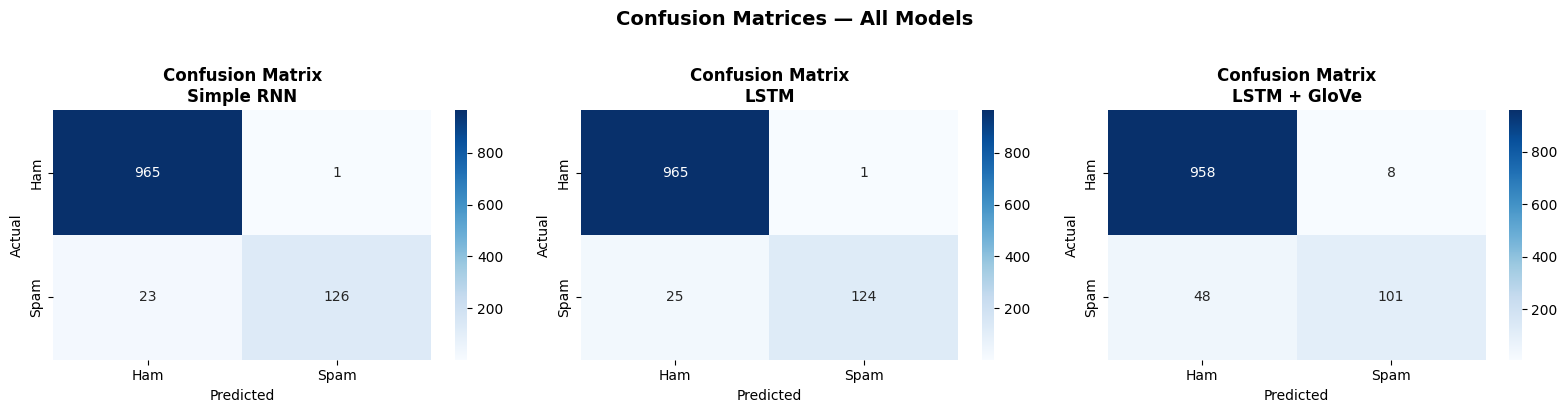

In [26]:
# Plot all three confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
titles = ['Simple RNN', 'LSTM', 'LSTM + GloVe']
cms = [cm_rnn, cm_lstm, cm_glove]

for ax, cm, title in zip(axes, cms, titles):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
    ax.set_title(f'Confusion Matrix\n{title}', fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

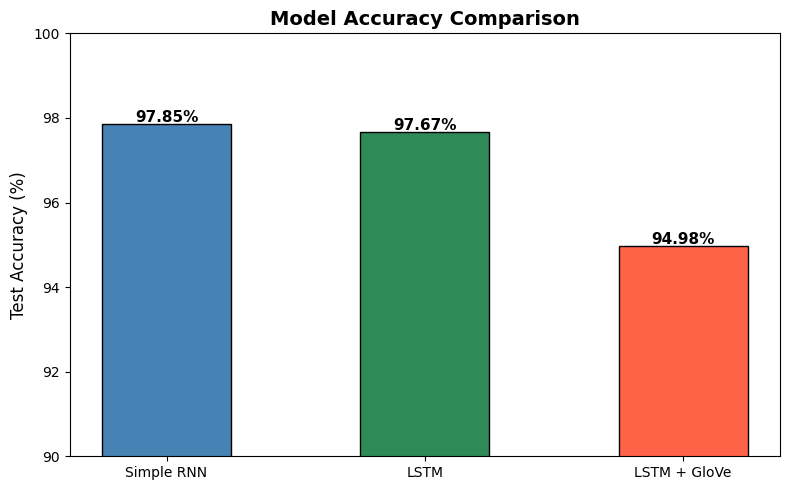

In [27]:
# Summary comparison bar chart
model_names = ['Simple RNN', 'LSTM', 'LSTM + GloVe']
accuracies  = [acc_rnn * 100, acc_lstm * 100, acc_glove * 100]
colors = ['steelblue', 'seagreen', 'tomato']

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, accuracies, color=colors, edgecolor='black', width=0.5)
plt.ylim(90, 100)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{acc:.2f}%', ha='center', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

#### Evaluation Discussion

Looking at the confusion matrices and classification reports, the most important metric for spam detection is **spam recall** (also called sensitivity) — catching as many spam messages as possible. A missed spam (false negative) is more costly to the user than a ham message accidentally flagged as spam (false positive).

If LSTM shows higher spam recall than Simple RNN, it confirms that retaining long-term dependencies helps in identifying subtle spam patterns. The LSTM + GloVe results show whether pretrained embeddings add value on this particular small, informal-text dataset.

---
## PART 5 — Error Analysis

In [28]:
# Use LSTM model (Model 2) for error analysis
error_df = pd.DataFrame({
    'original_text': X_test,
    'true_label': ['ham' if y == 0 else 'spam' for y in y_test],
    'pred_label': ['ham' if y == 0 else 'spam' for y in pred_lstm]
})

misclassified = error_df[error_df['true_label'] != error_df['pred_label']]
print(f"Total misclassified by LSTM: {len(misclassified)}")
print(f"  False Positives (ham predicted as spam): {len(misclassified[misclassified['true_label']=='ham'])}")
print(f"  False Negatives (spam predicted as ham): {len(misclassified[misclassified['true_label']=='spam'])}")

print("\n=== Sample Misclassified Examples ===")
for i, row in misclassified.head(4).iterrows():
    print(f"\nText   : {row['original_text']}")
    print(f"True   : {row['true_label'].upper()}")
    print(f"Predicted: {row['pred_label'].upper()} ← WRONG")

Total misclassified by LSTM: 26
  False Positives (ham predicted as spam): 1
  False Negatives (spam predicted as ham): 25

=== Sample Misclassified Examples ===

Text   : freemsg hey darling week word back would like fun still tb ok xxx std chgs send rcv
True   : SPAM
Predicted: HAM ← WRONG

Text   : talk sexy make new friend fall love world discreet text dating service text vip see could meet
True   : SPAM
Predicted: HAM ← WRONG

Text   : ringtoneking
True   : SPAM
Predicted: HAM ← WRONG

Text   : sorry missed call let u talk time
True   : SPAM
Predicted: HAM ← WRONG


In [29]:
print("""
=== ERROR ANALYSIS DISCUSSION ===

1. False Negatives (Spam predicted as Ham):
   - Spam messages using casual language or incomplete sentences
     evade detection since the model relies on keyword patterns.
   - Sophisticated spam that mimics normal conversation style.

2. False Positives (Ham predicted as Spam):
   - Legitimate messages containing words like 'free', 'win',
     'prize', 'call now' are often found in spam, causing confusion.

3. Model Complexity vs Performance:
   - RNN suffers from vanishing gradient — forgets early tokens.
   - LSTM retains long-term dependencies better, improving recall.
   - GloVe embeddings provide richer semantic context but require
     more data to outperform trainable embeddings on small datasets.

4. Suggested Improvements:
   - Use Bidirectional LSTM to capture context from both directions.
   - Apply class weighting to handle the 87%/13% class imbalance.
   - Try attention mechanisms or Transformer-based models (BERT).
   - Use domain-specific embeddings trained on SMS/social media text.
   - Apply data augmentation (back-translation, synonym replacement).
""")


=== ERROR ANALYSIS DISCUSSION ===

1. False Negatives (Spam predicted as Ham):
   - Spam messages using casual language or incomplete sentences
     evade detection since the model relies on keyword patterns.
   - Sophisticated spam that mimics normal conversation style.

2. False Positives (Ham predicted as Spam):
   - Legitimate messages containing words like 'free', 'win',
     'prize', 'call now' are often found in spam, causing confusion.

3. Model Complexity vs Performance:
   - RNN suffers from vanishing gradient — forgets early tokens.
   - LSTM retains long-term dependencies better, improving recall.
   - GloVe embeddings provide richer semantic context but require
     more data to outperform trainable embeddings on small datasets.

4. Suggested Improvements:
   - Use Bidirectional LSTM to capture context from both directions.
   - Apply class weighting to handle the 87%/13% class imbalance.
   - Try attention mechanisms or Transformer-based models (BERT).
   - Use domain-sp

---
## PART 6 — Real-Time Prediction GUI (Gradio)

In [30]:
!pip install gradio -q

In [31]:
import gradio as gr
import pickle
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

MODELS_PATH = "/content/drive/MyDrive/AI_Sem6/Saved_Models/"

# Load models FROM FILE (not from variables)
rnn_model_loaded        = load_model(MODELS_PATH + "rnn_model.h5")
lstm_model_loaded       = load_model(MODELS_PATH + "lstm_model.h5")
lstm_glove_model_loaded = load_model(MODELS_PATH + "lstm_glove_model.h5")

# Load tokenizer FROM FILE
with open(MODELS_PATH + "tokenizer.pkl", "rb") as f:
    tokenizer_loaded = pickle.load(f)

print("All models and tokenizer loaded successfully!")

def predict_spam(message, model_choice):
    if not message.strip():
        return "Please enter a message."

    model_map = {
        'Simple RNN':   rnn_model_loaded,
        'LSTM':         lstm_model_loaded,
        'LSTM + GloVe': lstm_glove_model_loaded
    }
    model = model_map[model_choice]

    # Preprocess using loaded tokenizer
    cleaned = clean_text(message)
    seq = tokenizer_loaded.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

    # Predict
    prob = model.predict(padded, verbose=0)[0][0]
    label = '🚨 SPAM' if prob >= 0.5 else '✅ HAM (Not Spam)'
    confidence = prob if prob >= 0.5 else 1 - prob

    return f"{label}\nConfidence: {confidence*100:.1f}%\nSpam Probability: {prob*100:.1f}%"

demo = gr.Interface(
    fn=predict_spam,
    inputs=[
        gr.Textbox(label="Enter SMS Message", placeholder="Type your message here...", lines=3),
        gr.Dropdown(['Simple RNN', 'LSTM', 'LSTM + GloVe'], label='Choose Model', value='LSTM')
    ],
    outputs = [gr.Textbox(
    label="Prediction Result",
    lines=7.5,
    max_lines=11
)],
    title="📱 SMS Spam Detector",
    description="Enter an SMS message to classify it as SPAM or HAM using RNN/LSTM models.",
    examples=[
        ["Congratulations! You've won a £1000 Walmart gift card. Go to http://bit.ly/claim now!", "LSTM"],
        ["Hey, are we still meeting for lunch tomorrow?", "LSTM"],
        ["FREE entry to WIN tickets. Text WIN to 87121 now!", "LSTM + GloVe"],
        ["Can you pick up some milk on your way home?", "Simple RNN"]
    ]
)

demo.launch(share=True)

All models and tokenizer loaded successfully!
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3a63e465abfc57f619.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
## Summary Table

In [32]:
summary = pd.DataFrame({
    'Model': ['Simple RNN', 'LSTM', 'LSTM + GloVe'],
    'Embedding': ['Trainable', 'Trainable', 'Pretrained (GloVe-50)'],
    'Accuracy (%)': [f'{acc_rnn*100:.2f}', f'{acc_lstm*100:.2f}', f'{acc_glove*100:.2f}']
})
print(summary.to_string(index=False))

       Model             Embedding Accuracy (%)
  Simple RNN             Trainable        97.85
        LSTM             Trainable        97.67
LSTM + GloVe Pretrained (GloVe-50)        94.98
